# Final Project: Phân tích các yếu tố nguy cơ và dự đoán bệnh tim

## Dataset: Cardiovascular Disease Dataset

### Thành viên nhóm
1. Nguyễn Đình Quốc Khánh
2. Trần Thảo Nguyên
3. Nguyễn Duy Trọng

## 1. Gather data 


### **1.1.** Problem Statement

Dự án này nhằm thực hành các kỹ năng xử lý dữ liệu bằng cách sử dụng các bộ dữ liệu thực tế.

Trong project này, nhóm sử dụng dữ liệu bệnh tim mạch để phân tích các yếu tố nguy cơ liên quan đến bệnh tim. Bệnh tim mạch là một vấn đề sức khỏe nghiêm trọng và có thể bị ảnh hưởng bởi nhiều yếu tố như tuổi tác, giới tính, chiều cao, cân nặng, huyết áp, cholesterol, đường huyết, thói quen hút thuốc, uống rượu và mức độ hoạt động thể chất.

Mục tiêu của project là thực hành quy trình data wrangling bao gồm thu thập dữ liệu, đánh giá dữ liệu, làm sạch dữ liệu, merge hai dataset, trực quan hóa dữ liệu và trả lời các câu hỏi nghiên cứu. Ngoài ra, project cũng xây dựng một mô hình dự đoán cơ bản để dự đoán khả năng mắc bệnh tim của bệnh nhân.

Trong bộ dữ liệu này, tôi muốn trả lời các câu hỏi nghiên cứu sau:

Question 1: Phân bố độ tuổi của bệnh nhân trong dataset như thế nào? (Trọng)

Question 2: Tỷ lệ bệnh nhân mắc bệnh tim và không mắc bệnh tim là bao nhiêu? (Trọng)

Question 3: Huyết áp tâm thu có liên quan đến tình trạng bệnh tim không? (Nguyên)

Question 4: Mức cholesterol ảnh hưởng như thế nào đến tỷ lệ mắc bệnh tim? (Nguyên)

Question 5: BMI có liên quan đến bệnh tim không? (Khánh)

Question 6: Các yếu tố lối sống như hút thuốc, uống rượu và vận động thể chất có liên quan đến bệnh tim không? (Khánh)

### **1.2.** Gather at least two datasets using two different data gathering methods


Trong dự án này, tôi đã thu thập hai bộ dữ liệu được tách ra từ Bộ dữ liệu Bệnh Tim Mạch gốc.

Bộ dữ liệu đầu tiên là `cardio_clinical_indicators1.csv`. Nó chứa các chỉ số nhân khẩu học và sức khỏe lâm sàng, bao gồm tuổi, giới tính, chiều cao, cân nặng, huyết áp, cholesterol, mức đường huyết và tình trạng bệnh tim mạch.

Bộ dữ liệu thứ hai là `cardio_lifestyle_factors1.csv`. Nó chứa các yếu tố liên quan đến lối sống, bao gồm tình trạng hút thuốc, uống rượu và hoạt động thể chất.

Cả hai bộ dữ liệu đều có chung khóa `id`. Do đó, chúng có thể được hợp nhất chính xác bằng cột này. Vì hai bộ dữ liệu được tách ra từ cùng một bộ dữ liệu gốc nên cùng một `id` đại diện cho cùng một bệnh nhân trong cả hai bộ dữ liệu.

In [5]:
# Nhập các thư viện:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

### **Thông tin bộ dữ liệu:**

- **Nguồn:** Kaggle  
- **Tên bộ dữ liệu gốc:** *Cardiovascular Disease Dataset*  
- **Liên kết bộ dữ liệu:** https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset  

- **Bộ dữ liệu 1:** `cardio_clinical_indicators1.csv`  
- **Mô tả:** Bộ dữ liệu này chứa các chỉ số nhân khẩu học và sức khỏe lâm sàng, bao gồm ID bệnh nhân, độ tuổi, giới tính, chiều cao, cân nặng, huyết áp tâm thu, huyết áp tâm trương, mức cholesterol, mức đường huyết và tình trạng bệnh tim mạch.

- **Bộ dữ liệu 2:** `cardio_lifestyle_factors1.csv`  
- **Mô tả:** Bộ dữ liệu này chứa các yếu tố liên quan đến lối sống, bao gồm ID bệnh nhân, tình trạng hút thuốc, uống rượu và hoạt động thể chất.

- **Khóa hợp nhất:** `id`  
- **Bộ dữ liệu cuối cùng:** Hai bộ dữ liệu được hợp nhất bằng khóa chung `id`. Bộ dữ liệu hợp nhất được sử dụng để phân tích các yếu tố rủi ro của bệnh tim mạch và xây dựng một mô hình dự đoán cơ bản.

### Trần Thảo Nguyên

In [2]:
# Điền phương pháp thu thập và tải dữ liệu thứ 1
clinical_df = pd.read_csv("cardio_clinical_indicators1.csv", sep=";")

clinical_df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio
0,0,18393,2,168,62.0,110,80,1,1,0
1,1,20228,1,156,85.0,140,90,3,1,1
2,2,18857,1,165,64.0,130,70,3,1,1
3,3,17623,2,169,82.0,150,100,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0


### Nguyễn Đình Quốc Khánh


In [3]:
# Điền phương pháp thu thập và tải dữ liệu thứ 2
lifestyle_df = pd.read_csv("cardio_lifestyle_factors1.csv", sep=";")

lifestyle_df.head()    

,id,smoke,alco,active
0,0,0,0,1
1,1,0,0,1
2,2,0,0,0
3,3,0,0,1
4,4,0,0,0


### Nguyễn Duy Trọng

In [4]:
# Ghi dữ liệu ra tệp cục bộ
# Lưu bản sao của hai bộ dữ liệu

clinical_df.to_csv("cardio_clinical_indicators1.csv", index=False, sep=";")
lifestyle_df.to_csv("cardio_lifestyle_factors1.csv", index=False, sep=";")

print("Two datasets were saved successfully.")

Two datasets were saved successfully.


## 2. Assess data


Tôi sẽ đánh giá dữ liệu cả bằng trực quan và lập trình để xác định bất kỳ vấn đề nào về chất lượng dữ liệu (nội dung) và sự gọn gàng (cấu trúc).

Trong phần này, tôi đánh giá hai bộ dữ liệu một cách riêng biệt:

- **Dataset 1:** `cardio_clinical_indicators1.csv`
- **Dataset 2:** `cardio_lifestyle_factors1.csv`

Đánh giá được dựa trên các khía cạnh chính của chất lượng dữ liệu:

1. Tính đầy đủ (Completeness)  
2. Tính hợp lệ (Validity)  
3. Tính chính xác (Accuracy)  
4. Tính nhất quán (Consistency)  
5. Tính duy nhất (Uniqueness)  

## 2.1. Đánh giá Bộ dữ liệu 1: Các chỉ số lâm sàng

Bộ dữ liệu đầu tiên là `cardio_clinical_indicators1.csv`. Bộ dữ liệu này chứa các chỉ số nhân khẩu học và sức khỏe lâm sàng, bao gồm tuổi, giới tính, chiều cao, cân nặng, huyết áp tâm thu, huyết áp tâm trương, mức cholesterol, mức đường huyết và tình trạng bệnh tim mạch.

### Trần Thảo Nguyên

### Vấn đề 1: Kiểu dữ liệu và cấu trúc

In [5]:
# Kiểm tra dataframe trực quan

clinical_df.sample(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio
2319,3267,17506,2,165,78.0,120,80,1,1,0
8349,11920,22552,1,169,68.0,16,90,2,1,1
65720,93809,16829,2,177,81.0,110,70,1,3,0
56760,81027,23190,2,160,103.0,130,90,3,3,1
29559,42257,18244,1,170,70.0,120,80,1,1,1


In [6]:
# Kiểm tra dataframe bằng code
clinical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   cardio       70000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 5.3 MB


#### Observations:

- Loại dữ liệu (Data types):
  - `int64`: Dữ liệu số nguyên – dùng cho `id`, `age`, `gender`, `height`, `ap_hi`, `ap_lo`, `cholesterol`, `gluc`, `cardio`.
  - `float64`: Dữ liệu số thực – dùng cho `weight`.
- Dataset `clinical_df` chứa các chỉ số nhân khẩu học và chỉ số y khoa của bệnh nhân.
- Cột `age` hiện tại đang được tính theo ngày, chưa thuận tiện cho việc phân tích và trực quan hóa theo độ tuổi.
- Cột `id` chỉ là mã định danh bệnh nhân, không mang ý nghĩa phân tích trực tiếp.
- Các cột `gender`, `cholesterol`, `gluc`, và `cardio` tuy có kiểu dữ liệu số nhưng thực chất là biến phân loại được mã hóa.

### Nguyễn Đình Quốc Khánh

### Vấn đề 2: 

In [7]:
clinical_df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
cardio         0
dtype: int64

#### Observations:

- Dataset `clinical_df` được kiểm tra dữ liệu bị thiếu bằng `.isnull().sum()`.
- Các cột `id`, `age`, `gender`, `height`, `weight`, `ap_hi`, `ap_lo`, `cholesterol`, `gluc`, và `cardio` không có giá trị thiếu.
- Điều này cho thấy dataset clinical khá đầy đủ về mặt dữ liệu.
- Vì không có missing values, nhóm không cần xóa dòng hoặc điền giá trị thay thế cho dataset này.

### Nguyễn Duy Trọng

### Vấn đề 3: 

In [8]:
clinical_df.duplicated().sum()

np.int64(0)

In [9]:
clinical_df["id"].duplicated().sum()

np.int64(0)

#### Observations:

- Dataset `clinical_df` không có dòng trùng lặp hoàn toàn vì kết quả `clinical_df.duplicated().sum()` bằng 0.
- Cột `id` cũng không có giá trị bị trùng vì kết quả `clinical_df["id"].duplicated().sum()` bằng 0.
- Điều này cho thấy mỗi bệnh nhân chỉ xuất hiện một lần trong dataset.
- Vì không có duplicated rows hoặc duplicated IDs, nhóm không cần loại bỏ dòng trùng lặp ở dataset clinical.

### Nguyễn Đình Quốc Khánh

### Vấn đề 4:

In [10]:
clinical_df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000


In [11]:
clinical_df[["height", "weight", "ap_hi", "ap_lo"]].describe()

,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000
mean,164.359229,74.205690,128.817286,96.630414
std,8.210126,14.395757,154.011419,188.472530
min,55.000000,10.000000,-150.000000,-70.000000
25%,159.000000,65.000000,120.000000,80.000000
50%,165.000000,72.000000,120.000000,80.000000
75%,170.000000,82.000000,140.000000,90.000000
max,250.000000,200.000000,16020.000000,11000.000000


In [12]:
clinical_df[["gender", "cholesterol", "gluc", "cardio"]].nunique()

gender         2
cholesterol    3
gluc           3
cardio         2
dtype: int64

#### Observations:

- Chiều cao (`height`):
  - Giá trị nhỏ nhất là `55 cm`, thấp hơn rất nhiều so với chiều cao hợp lý của người trưởng thành.
  - Giá trị lớn nhất là `250 cm`, cao bất thường.
  - Vì vậy, cột `height` có thể chứa một số giá trị ngoại lai cần xử lý.

- Cân nặng (`weight`):
  - Giá trị nhỏ nhất là `10 kg`, không hợp lý đối với người trưởng thành.
  - Giá trị lớn nhất là `200 kg`, rất cao nhưng vẫn có thể xuất hiện trong một số trường hợp đặc biệt.
  - Cần lọc cân nặng theo khoảng hợp lý để tránh ảnh hưởng đến BMI.

- Huyết áp tâm thu (`ap_hi`):
  - Giá trị nhỏ nhất là `-150`, đây là giá trị không hợp lệ vì huyết áp không thể âm.
  - Giá trị lớn nhất là `16020`, quá cao và không thực tế.
  - Cột này có nhiều giá trị bất thường cần được làm sạch.

- Huyết áp tâm trương (`ap_lo`):
  - Giá trị nhỏ nhất là `-70`, không hợp lệ vì huyết áp không thể âm.
  - Giá trị lớn nhất là `11000`, quá cao và không thực tế.
  - Cần xử lý các giá trị bất thường ở cột này.

- Các biến phân loại:
  - `gender` có 2 giá trị khác nhau, phù hợp với mã hóa giới tính.
  - `cholesterol` có 3 giá trị khác nhau, phù hợp với mức cholesterol 1, 2, 3.
  - `gluc` có 3 giá trị khác nhau, phù hợp với mức glucose 1, 2, 3.
  - `cardio` có 2 giá trị khác nhau, phù hợp với biến mục tiêu 0 và 1.

- Tổng quan:
  - Dataset có đầy đủ các biến cần thiết để phân tích bệnh tim.
  - Tuy nhiên, một số cột như `height`, `weight`, `ap_hi`, và `ap_lo` có giá trị bất thường.
  - Các giá trị này cần được xử lý ở bước cleaning để kết quả phân tích và mô hình dự đoán chính xác hơn.

## 2.2. Đánh giá Bộ dữ liệu 2: Các yếu tố lối sống

Bộ dữ liệu thứ hai chứa các yếu tố liên quan đến lối sống như tình trạng hút thuốc, uống rượu và hoạt động thể chất.

### Nguyễn Đình Quốc Khánh

### Vấn đề 1:

In [13]:
lifestyle_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      70000 non-null  int64
 1   smoke   70000 non-null  int64
 2   alco    70000 non-null  int64
 3   active  70000 non-null  int64
dtypes: int64(4)
memory usage: 2.1 MB


#### Observations:

- Loại dữ liệu (Data types):
  - `int64`: Dữ liệu số nguyên – dùng cho `id`, `smoke`, `alco`, `active`.
- Dataset `lifestyle_df` chứa các yếu tố lối sống của bệnh nhân, bao gồm:
  - `smoke`: tình trạng hút thuốc
  - `alco`: tình trạng uống rượu
  - `active`: tình trạng hoạt động thể chất
- Các cột `smoke`, `alco`, và `active` đang ở dạng số nguyên nhưng thực chất là biến phân loại nhị phân.
- Cột `id` là mã định danh bệnh nhân và là khóa chung dùng để merge với dataset `clinical_df`.
- Dataset này có cấu trúc đơn giản, gọn và phù hợp để merge với dataset clinical indicators.

### Trần Thảo Nguyên

### Vấn đề  2:

In [14]:
lifestyle_df.isnull().sum()

id        0
smoke     0
alco      0
active    0
dtype: int64

#### Observations:

- Dataset `lifestyle_df` được kiểm tra dữ liệu bị thiếu bằng `.isnull().sum()`.
- Các cột `id`, `smoke`, `alco`, và `active` không có giá trị thiếu.
- Điều này cho thấy dữ liệu về các yếu tố lối sống khá đầy đủ.
- Vì không có missing values, nhóm không cần xóa dòng hoặc điền giá trị thay thế cho dataset này.

### Nguyễn Duy Trọng

### Issue 3:

In [15]:
lifestyle_df.duplicated().sum()

np.int64(0)

In [ ]:
lifestyle_df["id"].duplicated().sum()

np.int64(0)

#### Observations:

- Dataset `lifestyle_df` không có dòng trùng lặp hoàn toàn.
- Cột `id` không có giá trị trùng lặp, nghĩa là mỗi bệnh nhân chỉ xuất hiện một lần.
- Vì vậy, không cần xử lý duplicated records cho dataset này trước khi merge.

### Trần Thảo Nguyên

### Vấn đề 4:

In [16]:
lifestyle_df.describe()

,id,smoke,alco,active
count,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.088129,0.053771,0.803729
std,28851.302323,0.283484,0.225568,0.397179
min,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,0.000000,0.000000,1.000000
50%,50001.500000,0.000000,0.000000,1.000000
75%,74889.250000,0.000000,0.000000,1.000000
max,99999.000000,1.000000,1.000000,1.000000


In [17]:
lifestyle_df[["smoke", "alco", "active"]].nunique()

smoke     2
alco      2
active    2
dtype: int64

In [18]:
for col in ["smoke", "alco", "active"]:
    print(col)
    print(lifestyle_df[col].value_counts())
    print("-" * 30)

smoke
smoke
0    63831
1     6169
Name: count, dtype: int64
------------------------------
alco
alco
0    66236
1     3764
Name: count, dtype: int64
------------------------------
active
active
1    56261
0    13739
Name: count, dtype: int64
------------------------------


#### Observations:

- Các yếu tố lối sống (`smoke`, `alco`, `active`):
  - Đây là các biến nhị phân, trong đó `0` = Không và `1` = Có.
  - `smoke` thể hiện tình trạng hút thuốc.
  - `alco` thể hiện tình trạng uống rượu.
  - `active` thể hiện tình trạng hoạt động thể chất.

- Kết quả kiểm tra số giá trị khác nhau cho thấy mỗi cột lifestyle chỉ nên có 2 giá trị là `0` và `1`.
- Nếu xuất hiện giá trị khác `0` hoặc `1`, đó sẽ là giá trị không hợp lệ và cần xử lý ở bước cleaning.
- Các biến lifestyle này sẽ được dùng để phân tích mối liên hệ giữa thói quen sống và nguy cơ mắc bệnh tim.

## 2.3. Tóm tắt đánh giá

Sau khi đánh giá hai bộ dữ liệu, các vấn đề sau đã được xác định:

### Bộ dữ liệu 1: Các chỉ số lâm sàng

1. `age` được lưu bằng ngày và nên được chuyển đổi sang năm.
2. `id` chỉ là một mã định danh và không nên được sử dụng như một biến phân tích.
3. Một số giá trị lâm sàng như `height`, `weight`, `ap_hi` và `ap_lo` chứa các giá trị không thực tế.
4. Giá trị huyết áp nên được kiểm tra vì `ap_hi` thông thường phải lớn hơn `ap_lo`.

### Bộ dữ liệu 2: Các yếu tố lối sống

1. Các biến lối sống được lưu dưới dạng giá trị nhị phân.
2. Các cột `smoke`, `alco`, và `active` chỉ nên chứa `0` và `1`.
3. Cột `id` được sử dụng làm khóa để hợp nhất với bộ dữ liệu lâm sàng.
4. Bộ dữ liệu nên được kiểm tra các dòng và ID trùng lặp trước khi hợp nhất.

### Vấn đề về sự gọn gàng (Tidiness)

Thông tin bệnh nhân bị chia thành hai bộ dữ liệu. Do đó, hai bộ dữ liệu nên được hợp nhất bằng khóa chung `id` trước khi phân tích.

## 3. Làm sạch dữ liệu

Trong phần này, tôi sẽ làm sạch dữ liệu dựa trên các vấn đề được xác định trong bước đánh giá dữ liệu.

Các bước làm sạch bao gồm:

1. Xóa các dòng trùng lặp nếu có.
2. Hợp nhất bộ dữ liệu chỉ số lâm sàng và bộ dữ liệu yếu tố lối sống bằng `id`.
3. Chuyển đổi `age` từ ngày sang năm.
4. Tạo cột BMI mới từ `height` và `weight`.
5. Xóa các giá trị không thực tế về chiều cao, cân nặng và huyết áp.
6. Tạo các nhãn dễ đọc cho các biến phân loại.

### Nguyễn Đình Quốc Khánh

### Vấn đề 1: Remove duplicated records

#### Định nghĩa

Trong bước đánh giá, cả hai bộ dữ liệu đã được kiểm tra các dòng và ID trùng lặp. Kết quả cho thấy không có dòng nào trùng lặp. Tuy nhiên, tôi vẫn sử dụng `drop_duplicates()` như một bước làm sạch an toàn trước khi hợp nhất.

In [19]:
# Tạo bản sao của các bộ dữ liệu gốc
clinical_clean = clinical_df.copy()
lifestyle_clean = lifestyle_df.copy()

# Xóa các dòng trùng lặp nếu có
clinical_clean = clinical_clean.drop_duplicates()
lifestyle_clean = lifestyle_clean.drop_duplicates()

In [20]:
print("Duplicated rows in clinical_clean:", clinical_clean.duplicated().sum())
print("Duplicated IDs in clinical_clean:", clinical_clean["id"].duplicated().sum())

print("Duplicated rows in lifestyle_clean:", lifestyle_clean.duplicated().sum())
print("Duplicated IDs in lifestyle_clean:", lifestyle_clean["id"].duplicated().sum())

Duplicated rows in clinical_clean: 0
Duplicated IDs in clinical_clean: 0
Duplicated rows in lifestyle_clean: 0
Duplicated IDs in lifestyle_clean: 0


#### Quan sát

Sau khi áp dụng `drop_duplicates()`, cả hai bộ dữ liệu không có dòng trùng lặp và không có ID bệnh nhân trùng lặp. Điều này đảm bảo rằng mỗi bệnh nhân chỉ xuất hiện một lần trong mỗi bộ dữ liệu trước khi hợp nhất.

### Trần Thảo Nguyên

### Vấn đề 2: Merge two datasets

#### Định nghĩa

Thông tin bệnh nhân bị chia thành hai bộ dữ liệu. Bộ dữ liệu lâm sàng chứa các chỉ số nhân khẩu học và lâm sàng, trong khi bộ dữ liệu lối sống chứa thông tin về hút thuốc, uống rượu và hoạt động thể chất.

Cả hai bộ dữ liệu chia sẻ chung khóa `id`, do đó chúng nên được hợp nhất thành một bộ dữ liệu bằng cột này.

In [21]:
# Hợp nhất các bộ dữ liệu lâm sàng và lối sống bằng id

df = pd.merge(
    clinical_clean,
    lifestyle_clean,
    on="id",
    how="left"
)

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio,smoke,alco,active
0,0,18393,2,168,62.0,110,80,1,1,0,0,0,1
1,1,20228,1,156,85.0,140,90,3,1,1,0,0,1
2,2,18857,1,165,64.0,130,70,3,1,1,0,0,0
3,3,17623,2,169,82.0,150,100,1,1,1,0,0,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [22]:
print("Clinical dataset shape:", clinical_clean.shape)
print("Lifestyle dataset shape:", lifestyle_clean.shape)
print("Merged dataset shape:", df.shape)

Clinical dataset shape: (70000, 10)
Lifestyle dataset shape: (70000, 4)
Merged dataset shape: (70000, 13)


In [23]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
cardio         0
smoke          0
alco           0
active         0
dtype: int64

#### Quan sát

Hai bộ dữ liệu đã được hợp nhất thành công bằng khóa chung `id`. Bộ dữ liệu hợp nhất chứa cả chỉ số lâm sàng và yếu tố lối sống. Bộ dữ liệu này sẽ được sử dụng để làm sạch, phân tích, trực quan hóa và dự đoán sâu hơn.

### Nguyễn Đình Quốc Khánh

### Vấn đề 3: Convert age from days to years

#### Định nghĩa

Cột `age` được lưu trữ bằng ngày, điều này gây khó khăn khi diễn giải trong phân tích và trực quan hóa. Do đó, tôi sẽ tạo một cột mới tên là `age_years` bằng cách chia `age` cho 365.

In [24]:
# Chuyển đổi tuổi từ ngày sang năm

df["age_years"] = (df["age"] / 365).round(1)

df[["age", "age_years"]].head()

,age,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.7
3,17623,48.3
4,17474,47.9


In [25]:
df["age_years"].describe()

count    70000.000000
mean        53.339486
std          6.759534
min         29.600000
25%         48.400000
50%         54.000000
75%         58.400000
max         65.000000
Name: age_years, dtype: float64

#### Quan sát

Cột mới `age_years` đã được tạo thành công. Nó hiển thị tuổi bệnh nhân theo năm, giúp dễ hiểu hơn và phù hợp hơn cho việc trực quan hóa và phân tích.

### Nguyễn Duy Trọng

### Vấn đề 4: Create BMI column

#### Định nghĩa

Bộ dữ liệu chứa `height` và `weight`, nhưng nó không chứa trực tiếp BMI. BMI là một phép đo cơ thể quan trọng có thể liên quan đến rủi ro mắc bệnh tim mạch.

BMI được tính bằng công thức:

BMI = weight / (height in meters)^2

In [26]:
# Tính toán BMI

df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

df[["height", "weight", "BMI"]].head()

,height,weight,BMI
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


In [27]:
df["BMI"].describe()

count    70000.000000
mean        27.556513
std          6.091511
min          3.471784
25%         23.875115
50%         26.374068
75%         30.222222
max        298.666667
Name: BMI, dtype: float64

#### Quan sát

Cột mới `BMI` đã được tạo thành công từ `height` và `weight`. Biến này sẽ được sử dụng để phân tích mối quan hệ giữa chỉ số khối cơ thể và bệnh tim mạch.

### Trần Thảo Nguyên

### Vấn đề 5: Loại bỏ các giá trị lâm sàng không thực tế

#### Định nghĩa

Trong bước đánh giá, một số giá trị không thực tế đã được tìm thấy trong `height`, `weight`, `ap_hi` và `ap_lo`.

Ví dụ:
- `height` (chiều cao) tối thiểu là 55 cm, điều này không thực tế đối với một người trưởng thành.
- `weight` (cân nặng) tối thiểu là 10 kg, điều này không thực tế đối với một người trưởng thành.
- `ap_hi` có các giá trị âm và rất cao.
- `ap_lo` cũng có các giá trị âm và rất cao.
- `ap_hi` thông thường nên lớn hơn `ap_lo`.

Do đó, tôi sẽ lọc bộ dữ liệu bằng các khoảng hợp lý.

In [28]:
# Lọc các giá trị hợp lý cho chiều cao, cân nặng, huyết áp và BMI

df_clean = df[
    (df["height"] >= 120) & (df["height"] <= 220) &
    (df["weight"] >= 30) & (df["weight"] <= 200) &
    (df["ap_hi"] >= 80) & (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) & (df["ap_lo"] <= 150) &
    (df["ap_hi"] > df["ap_lo"]) &
    (df["BMI"] >= 10) & (df["BMI"] <= 60)
]

df_clean.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio,smoke,alco,active,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,0,1,50.4,21.967120
1,1,20228,1,156,85.0,140,90,3,1,1,0,0,1,55.4,34.927679
2,2,18857,1,165,64.0,130,70,3,1,1,0,0,0,51.7,23.507805
3,3,17623,2,169,82.0,150,100,1,1,1,0,0,1,48.3,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.9,23.011177


In [29]:
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Shape before cleaning: (70000, 15)
Shape after cleaning: (68583, 15)
Rows removed: 1417


In [30]:
df_clean[["height", "weight", "ap_hi", "ap_lo", "BMI"]].describe()

,height,weight,ap_hi,ap_lo,BMI
count,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000
mean,164.417800,74.088607,126.670822,81.302816,27.444104
std,7.904775,14.212808,16.669511,9.417221,5.198859
min,120.000000,30.000000,80.000000,40.000000,10.726644
25%,159.000000,65.000000,120.000000,80.000000,23.875115
50%,165.000000,72.000000,120.000000,80.000000,26.346494
75%,170.000000,82.000000,140.000000,90.000000,30.116213
max,207.000000,200.000000,240.000000,150.000000,59.523810


#### Quan sát

Sau khi lọc các giá trị không hợp lý, bộ dữ liệu chứa các giá trị thực tế hơn cho chiều cao, cân nặng, huyết áp và BMI. Điều này giúp giảm thiểu tác động của các giá trị ngoại lai đối với trực quan hóa, phân tích và dự đoán.

### Nguyễn Duy Trọng

### Vấn đề 6: Tạo các nhãn dễ đọc cho các biến phân loại

#### Định nghĩa

Một số biến được mã hóa dưới dạng số, chẳng hạn như `cardio`, `gender`, `cholesterol`, `gluc`, `smoke`, `alco` và `active`. Để dễ trực quan hóa và diễn giải hơn, tôi sẽ tạo các cột có nhãn dễ đọc.

In [31]:
# Tạo nhãn dễ đọc cho các biến phân loại

df_clean["cardio_label"] = df_clean["cardio"].map({
    0: "Không mắc bệnh tim",
    1: "Mắc bệnh tim"
})

df_clean["gender_label"] = df_clean["gender"].map({
    1: "Nữ",
    2: "Nam"
})

df_clean["cholesterol_label"] = df_clean["cholesterol"].map({
    1: "Bình thường",
    2: "Trên bình thường",
    3: "Cao"
})

df_clean["gluc_label"] = df_clean["gluc"].map({
    1: "Bình thường",
    2: "Trên bình thường",
    3: "Cao"
})

df_clean["smoke_label"] = df_clean["smoke"].map({
    0: "Không hút thuốc",
    1: "Có hút thuốc"
})

df_clean["alco_label"] = df_clean["alco"].map({
    0: "Không uống rượu",
    1: "Có uống rượu"
})

df_clean["active_label"] = df_clean["active"].map({
    0: "Không vận động",
    1: "Có vận động"
})

df_clean.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio,...,active,age_years,BMI,cardio_label,gender_label,cholesterol_label,gluc_label,smoke_label,alco_label,active_label
0,0,18393,2,168,62.0,110,80,1,1,0,...,1,50.4,21.967120,Không mắc bệnh tim,Nam,Bình thường,Bình thường,Không hút thuốc,Không uống rượu,Có vận động
1,1,20228,1,156,85.0,140,90,3,1,1,...,1,55.4,34.927679,Mắc bệnh tim,Nữ,Cao,Bình thường,Không hút thuốc,Không uống rượu,Có vận động
2,2,18857,1,165,64.0,130,70,3,1,1,...,0,51.7,23.507805,Mắc bệnh tim,Nữ,Cao,Bình thường,Không hút thuốc,Không uống rượu,Không vận động
3,3,17623,2,169,82.0,150,100,1,1,1,...,1,48.3,28.710479,Mắc bệnh tim,Nam,Bình thường,Bình thường,Không hút thuốc,Không uống rượu,Có vận động
4,4,17474,1,156,56.0,100,60,1,1,0,...,0,47.9,23.011177,Không mắc bệnh tim,Nữ,Bình thường,Bình thường,Không hút thuốc,Không uống rượu,Không vận động


In [32]:
df_clean[
    [
        "cardio", "cardio_label",
        "gender", "gender_label",
        "cholesterol", "cholesterol_label",
        "gluc", "gluc_label",
        "smoke", "smoke_label",
        "alco", "alco_label",
        "active", "active_label"
    ]
].head()

,cardio,cardio_label,gender,gender_label,cholesterol,cholesterol_label,gluc,gluc_label,smoke,smoke_label,alco,alco_label,active,active_label
0,0,Không mắc bệnh tim,2,Nam,1,Bình thường,1,Bình thường,0,Không hút thuốc,0,Không uống rượu,1,Có vận động
1,1,Mắc bệnh tim,1,Nữ,3,Cao,1,Bình thường,0,Không hút thuốc,0,Không uống rượu,1,Có vận động
2,1,Mắc bệnh tim,1,Nữ,3,Cao,1,Bình thường,0,Không hút thuốc,0,Không uống rượu,0,Không vận động
3,1,Mắc bệnh tim,2,Nam,1,Bình thường,1,Bình thường,0,Không hút thuốc,0,Không uống rượu,1,Có vận động
4,0,Không mắc bệnh tim,1,Nữ,1,Bình thường,1,Bình thường,0,Không hút thuốc,0,Không uống rượu,0,Không vận động


#### Quan sát

Các cột có nhãn dễ đọc đã được tạo thành công. Các nhãn này giúp bộ dữ liệu dễ hiểu hơn và cải thiện độ rõ nét của các biểu đồ trực quan hóa.

### Trần Thảo Nguyên

### Kiểm tra cuối cùng bộ dữ liệu đã làm sạch

In [33]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 68583 entries, 0 to 69999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 68583 non-null  int64  
 1   age                68583 non-null  int64  
 2   gender             68583 non-null  int64  
 3   height             68583 non-null  int64  
 4   weight             68583 non-null  float64
 5   ap_hi              68583 non-null  int64  
 6   ap_lo              68583 non-null  int64  
 7   cholesterol        68583 non-null  int64  
 8   gluc               68583 non-null  int64  
 9   cardio             68583 non-null  int64  
 10  smoke              68583 non-null  int64  
 11  alco               68583 non-null  int64  
 12  active             68583 non-null  int64  
 13  age_years          68583 non-null  float64
 14  BMI                68583 non-null  float64
 15  cardio_label       68583 non-null  str    
 16  gender_label       68583 non-null  str

In [34]:
df_clean.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio,smoke,alco,active,age_years,BMI
count,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000,68583.000000
mean,49977.078226,19464.622778,1.348672,164.417800,74.088607,126.670822,81.302816,1.364770,1.225785,0.494714,0.087966,0.053337,0.803319,53.327863,27.444104
std,28844.840080,2467.814351,0.476554,7.904775,14.212808,16.669511,9.417221,0.678983,0.571640,0.499976,0.283248,0.224706,0.397492,6.761085,5.198859
min,0.000000,10798.000000,1.000000,120.000000,30.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.600000,10.726644
25%,25008.500000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,48.400000,23.875115
50%,50017.000000,19701.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,54.000000,26.346494
75%,74871.500000,21324.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,58.400000,30.116213
max,99999.000000,23713.000000,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,59.523810


In [35]:
df_clean.isnull().sum()

id                   0
age                  0
gender               0
height               0
weight               0
ap_hi                0
ap_lo                0
cholesterol          0
gluc                 0
cardio               0
smoke                0
alco                 0
active               0
age_years            0
BMI                  0
cardio_label         0
gender_label         0
cholesterol_label    0
gluc_label           0
smoke_label          0
alco_label           0
active_label         0
dtype: int64

In [36]:
df_clean.duplicated().sum()

np.int64(0)

#### Quan sát cuối cùng

Bộ dữ liệu đã làm sạch giờ đây sẵn sàng cho việc phân tích và trực quan hóa. Nó chứa thông tin lâm sàng và lối sống đã hợp nhất, tuổi được chuyển đổi thành năm, BMI và các giá trị đã được làm sạch của các chỉ số cơ thể và huyết áp.

## 4. Cập nhật nơi lưu trữ dữ liệu của bạn
Cập nhật cơ sở dữ liệu/nơi lưu trữ bằng dữ liệu đã được làm sạch


In [37]:
# Điền vào - lưu dữ liệu
df_clean.to_csv("cardio_cleaned_dataset.csv", index=False, sep=";")

print("Cleaned dataset was saved successfully.")

Cleaned dataset was saved successfully.


## DỰ ÁN 1 DỪNG Ở ĐÂY



## DỰ ÁN 2 



## 5. Trả lời câu hỏi nghiên cứu

### **5.1:** Xác định và trả lời câu hỏi nghiên cứu 


### Question 1: Phân bố độ tuổi của bệnh nhân trong dataset như thế nào? (Trọng)

Biểu đồ histogram được sử dụng để quan sát phân bố độ tuổi của bệnh nhân trong dataset.

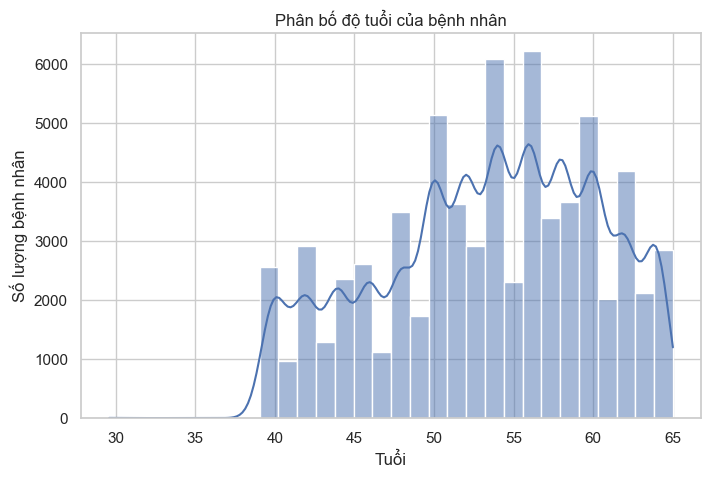

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean["age_years"], bins=30, kde=True)

plt.title("Phân bố độ tuổi của bệnh nhân")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng bệnh nhân")

plt.show()

In [39]:
df_clean["age_years"].describe()

count    68583.000000
mean        53.327863
std          6.761085
min         29.600000
25%         48.400000
50%         54.000000
75%         58.400000
max         65.000000
Name: age_years, dtype: float64

#### Observations:

- Biểu đồ histogram cho thấy độ tuổi của bệnh nhân trong dataset chủ yếu nằm trong khoảng từ khoảng 40 đến 65 tuổi.
- Số lượng bệnh nhân tăng dần từ nhóm khoảng 40 tuổi và tập trung nhiều nhất ở nhóm trung niên, đặc biệt khoảng 50–60 tuổi.
- Nhóm tuổi dưới 40 xuất hiện rất ít trong dataset.
- Điều này cho thấy dataset tập trung nhiều vào nhóm trung niên và người lớn tuổi, đây cũng là nhóm có nguy cơ mắc bệnh tim cao hơn.
- Vì vậy, tuổi là một yếu tố quan trọng cần được xem xét trong phân tích nguy cơ bệnh tim.

### Question 2: Tỷ lệ bệnh nhân mắc bệnh tim và không mắc bệnh tim là bao nhiêu? (Trọng)

Biểu đồ count plot được sử dụng để so sánh số lượng bệnh nhân mắc bệnh tim và không mắc bệnh tim.

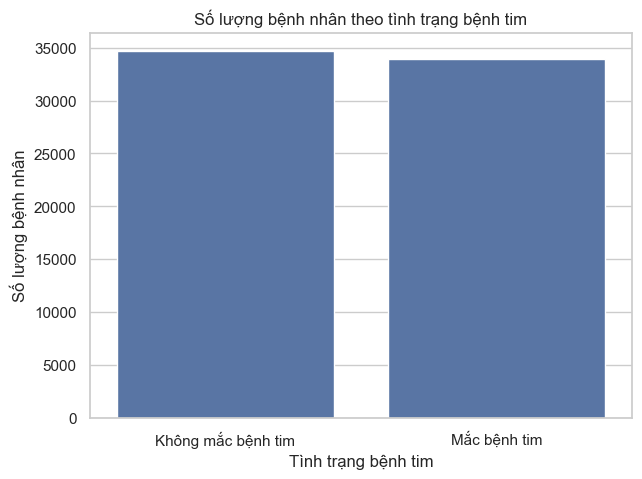

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="cardio_label")

plt.title("Số lượng bệnh nhân theo tình trạng bệnh tim")
plt.xlabel("Tình trạng bệnh tim")
plt.ylabel("Số lượng bệnh nhân")

plt.show()

In [41]:
cardio_count = df_clean["cardio_label"].value_counts()
cardio_rate = df_clean["cardio_label"].value_counts(normalize=True) * 100

print("Số lượng:")
print(cardio_count)

print("\nTỷ lệ phần trăm:")
print(cardio_rate.round(2))

Số lượng:
cardio_label
Không mắc bệnh tim    34654
Mắc bệnh tim          33929
Name: count, dtype: int64

Tỷ lệ phần trăm:
cardio_label
Không mắc bệnh tim    50.53
Mắc bệnh tim          49.47
Name: proportion, dtype: float64


#### Observations:

- Dataset có hai nhóm bệnh nhân: mắc bệnh tim và không mắc bệnh tim.
- Tỷ lệ giữa hai nhóm tương đối cân bằng.
- Điều này thuận lợi cho việc phân tích và xây dựng mô hình dự đoán vì dữ liệu không bị lệch quá nhiều về một nhóm.

### Question 3: Huyết áp tâm thu có liên quan đến tình trạng bệnh tim không? (Nguyên)

Biểu đồ bar chart được sử dụng để so sánh huyết áp tâm thu trung bình giữa nhóm mắc bệnh tim và nhóm không mắc bệnh tim.

In [42]:
# Tính huyết áp tâm thu trung bình theo tình trạng bệnh tim

ap_hi_mean = df_clean.groupby("cardio_label")["ap_hi"].mean().reset_index()

ap_hi_mean

,cardio_label,ap_hi
0,Không mắc bệnh tim,119.608847
1,Mắc bệnh tim,133.883698


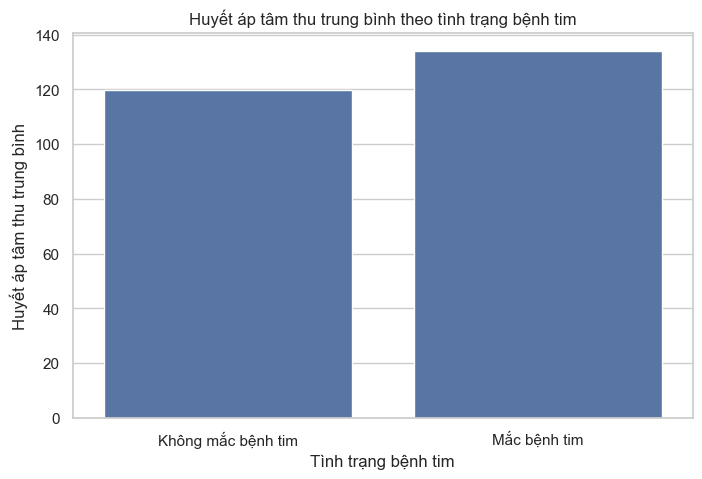

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(data=ap_hi_mean, x="cardio_label", y="ap_hi")

plt.title("Huyết áp tâm thu trung bình theo tình trạng bệnh tim")
plt.xlabel("Tình trạng bệnh tim")
plt.ylabel("Huyết áp tâm thu trung bình")

plt.show()

#### Observations:

- Biểu đồ cho thấy nhóm bệnh nhân mắc bệnh tim có huyết áp tâm thu trung bình cao hơn nhóm không mắc bệnh tim.
- Điều này cho thấy huyết áp tâm thu có liên quan đến tình trạng bệnh tim.
- Huyết áp tâm thu càng cao có thể làm tăng nguy cơ mắc bệnh tim.
- Vì vậy, `ap_hi` là một biến quan trọng trong phân tích và dự đoán bệnh tim.

### Question 4: Mức cholesterol ảnh hưởng như thế nào đến tỷ lệ mắc bệnh tim? (Nguyên)

Biểu đồ bar chart được sử dụng để thể hiện tỷ lệ mắc bệnh tim theo từng mức cholesterol.

In [44]:
cholesterol_cardio = df_clean.groupby("cholesterol_label")["cardio"].mean().reset_index()
cholesterol_cardio["cardio_rate"] = cholesterol_cardio["cardio"] * 100

cholesterol_cardio

,cholesterol_label,cardio,cardio_rate
0,Bình thường,0.435396,43.539637
1,Cao,0.762559,76.255882
2,Trên bình thường,0.596384,59.638360


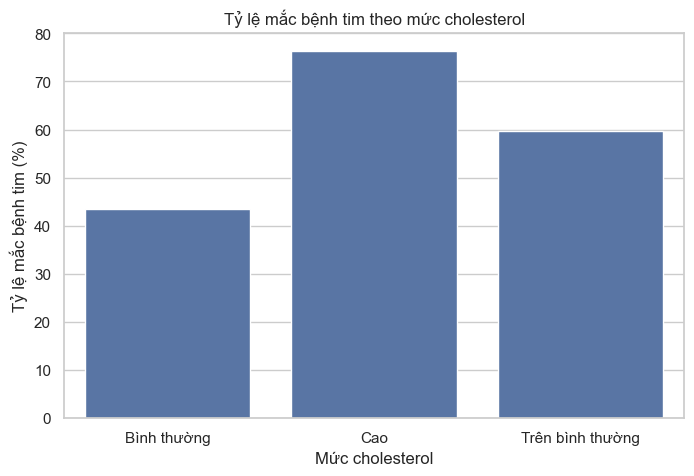

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(data=cholesterol_cardio, x="cholesterol_label", y="cardio_rate")

plt.title("Tỷ lệ mắc bệnh tim theo mức cholesterol")
plt.xlabel("Mức cholesterol")
plt.ylabel("Tỷ lệ mắc bệnh tim (%)")

plt.show()

#### Observations:

- Tỷ lệ mắc bệnh tim có xu hướng tăng khi mức cholesterol tăng.
- Nhóm có cholesterol cao thường có tỷ lệ mắc bệnh tim cao hơn nhóm cholesterol bình thường.
- Điều này cho thấy cholesterol là một yếu tố nguy cơ quan trọng trong phân tích bệnh tim.

### Question 5: BMI có liên quan đến bệnh tim không? (Khánh)

BMI được tính từ chiều cao và cân nặng. Scatter plot được sử dụng để quan sát mối quan hệ giữa tuổi, BMI và tình trạng bệnh tim.

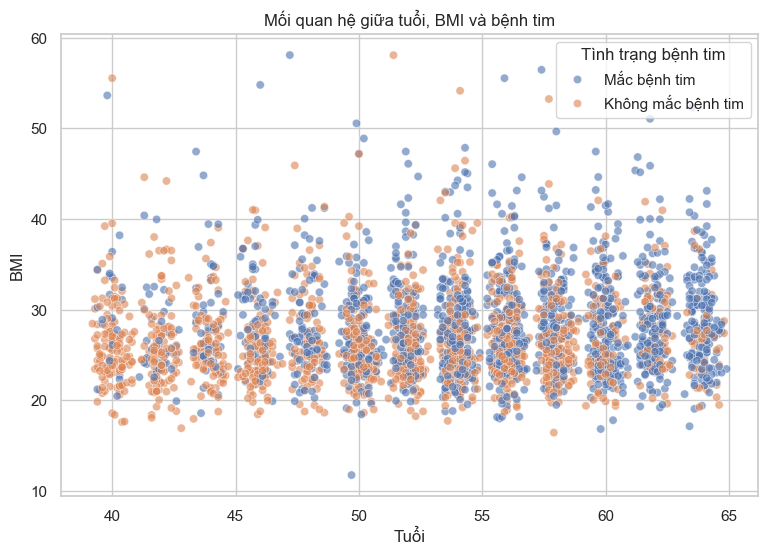

In [46]:
sample_df = df_clean.sample(3000, random_state=42)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_df,
    x="age_years",
    y="BMI",
    hue="cardio_label",
    alpha=0.6
)

plt.title("Mối quan hệ giữa tuổi, BMI và bệnh tim")
plt.xlabel("Tuổi")
plt.ylabel("BMI")
plt.legend(title="Tình trạng bệnh tim")

plt.show()

In [47]:
df_clean.groupby("cardio_label")["BMI"].mean().round(2)

cardio_label
Không mắc bệnh tim    26.46
Mắc bệnh tim          28.45
Name: BMI, dtype: float64

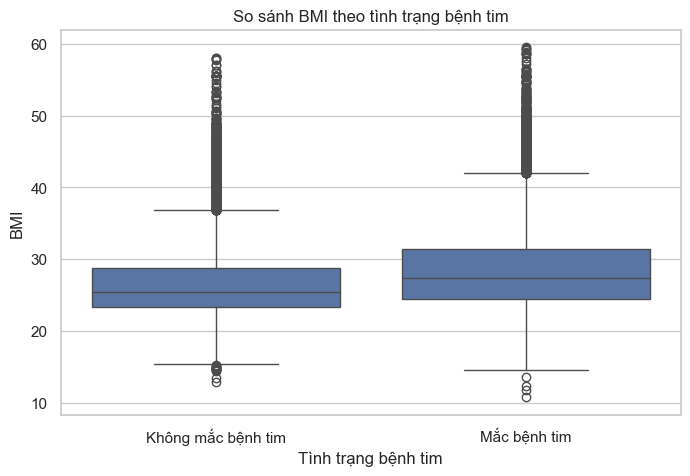

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="cardio_label", y="BMI")

plt.title("So sánh BMI theo tình trạng bệnh tim")
plt.xlabel("Tình trạng bệnh tim")
plt.ylabel("BMI")

plt.show()

#### Observations:

- Nhóm bệnh nhân mắc bệnh tim có xu hướng có BMI trung bình cao hơn nhóm không mắc bệnh tim.
- BMI cao có thể làm tăng nguy cơ mắc bệnh tim, đặc biệt khi kết hợp với tuổi cao và huyết áp cao.
- Scatter plot cho thấy bệnh tim xuất hiện nhiều ở nhóm tuổi trung niên/cao tuổi và ở một số bệnh nhân có BMI cao.

### Question 6: Các yếu tố lối sống như hút thuốc, uống rượu và vận động thể chất có liên quan đến bệnh tim không? (Khánh)

Ở câu hỏi này, nhóm phân tích ba yếu tố lối sống gồm:
- Hút thuốc
- Uống rượu
- Hoạt động thể chất

In [57]:
lifestyle_cols = ["smoke", "alco", "active"]

for col in lifestyle_cols:
    rate = df_clean.groupby(col)["cardio"].mean() * 100
    print(f"Tỷ lệ mắc bệnh tim theo {col}:")
    print(rate.round(2))
    print("-" * 40)

Tỷ lệ mắc bệnh tim theo smoke:
smoke
0    49.72
1    46.86
Name: cardio, dtype: float64
----------------------------------------
Tỷ lệ mắc bệnh tim theo alco:
alco
0    49.57
1    47.70
Name: cardio, dtype: float64
----------------------------------------
Tỷ lệ mắc bệnh tim theo active:
active
0    53.28
1    48.54
Name: cardio, dtype: float64
----------------------------------------


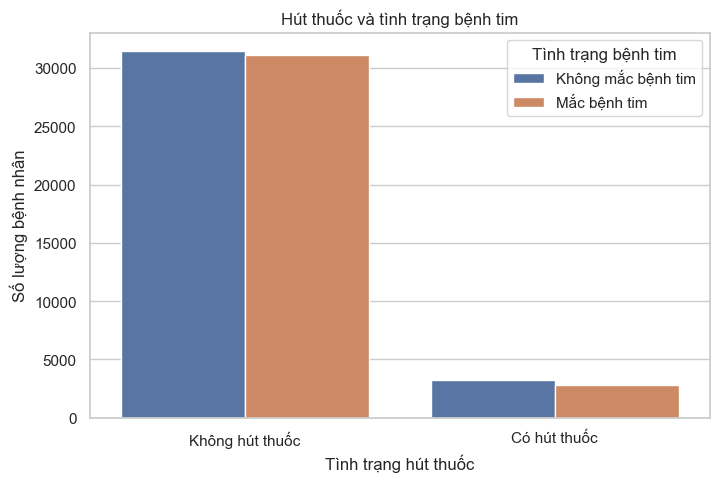

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="smoke_label", hue="cardio_label")

plt.title("Hút thuốc và tình trạng bệnh tim")
plt.xlabel("Tình trạng hút thuốc")
plt.ylabel("Số lượng bệnh nhân")
plt.legend(title="Tình trạng bệnh tim")

plt.show()

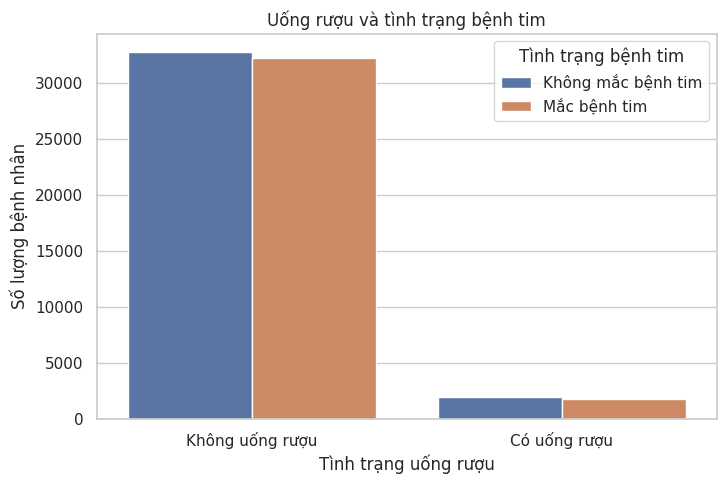

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="alco_label", hue="cardio_label")

plt.title("Uống rượu và tình trạng bệnh tim")
plt.xlabel("Tình trạng uống rượu")
plt.ylabel("Số lượng bệnh nhân")
plt.legend(title="Tình trạng bệnh tim")

plt.show()

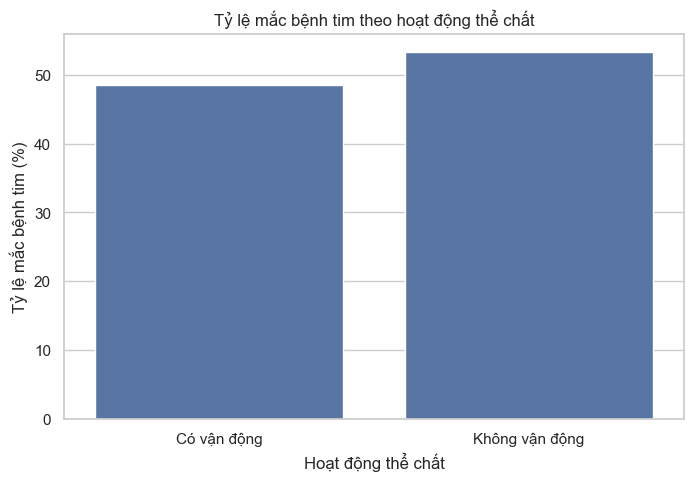

In [59]:
active_cardio = df_clean.groupby("active_label")["cardio"].mean().reset_index()
active_cardio["cardio_rate"] = active_cardio["cardio"] * 100

plt.figure(figsize=(8, 5))

sns.barplot(data=active_cardio, x="active_label", y="cardio_rate")

plt.title("Tỷ lệ mắc bệnh tim theo hoạt động thể chất")
plt.xlabel("Hoạt động thể chất")
plt.ylabel("Tỷ lệ mắc bệnh tim (%)")

plt.show()

#### Observations:

- Các yếu tố lối sống có sự liên quan nhất định đến tình trạng bệnh tim.
- Nhóm không vận động thể chất có thể có tỷ lệ mắc bệnh tim cao hơn nhóm có vận động.
- Hút thuốc và uống rượu cũng là các yếu tố cần được xem xét, tuy nhiên tác động của chúng có thể bị ảnh hưởng bởi các biến khác như tuổi, giới tính, huyết áp và cholesterol.
- Vì vậy, các yếu tố lối sống nên được phân tích cùng với các chỉ số y khoa để đánh giá nguy cơ bệnh tim chính xác hơn.

#### 5.2: Phản ánh (Reflection)

Sau tất cả các bước trên, nhóm đã xây dựng được bộ dữ liệu sạch từ hai nguồn dữ liệu bệnh tim mạch và trả lời được các câu hỏi nghiên cứu đề ra.

Thông qua các câu hỏi nghiên cứu, nhóm đã xác định được các yếu tố nguy cơ liên quan đến bệnh tim bao gồm: độ tuổi, huyết áp tâm thu, mức cholesterol, chỉ số BMI và các yếu tố lối sống như hút thuốc, uống rượu và vận động thể chất.

Trong tương lai, nhóm sẽ xem xét thêm sự tương tác giữa các yếu tố nguy cơ (ví dụ: bệnh nhân vừa có huyết áp cao vừa có cholesterol cao thì nguy cơ mắc bệnh tim tăng lên như thế nào), đồng thời cải thiện mô hình dự đoán. Ngoài ra, nhóm cũng sẽ kiểm tra thêm dữ liệu ở một số cột như gluc (đường huyết) và phân tích sâu hơn sự khác biệt giữa nam và nữ trong nguy cơ mắc bệnh tim.